=== 碰撞引导函数验证 ===

模拟参数: B=2, P=3, T=5, D=3

1. 生成模拟轨迹数据...
轨迹数据形状: torch.Size([2, 3, 5, 3])

预期碰撞分析:
时间步 0: 自车[0. 0.], 邻居1[ 5. -1.], 距离: 5.10
时间步 1: 自车[2.5  0.25], 邻居1[ 7.5  -0.25], 距离: 5.02
时间步 2: 自车[5.  0.5], 邻居1[10.   0.5], 距离: 5.00
时间步 3: 自车[7.5  0.75], 邻居1[12.5   1.25], 距离: 5.02
时间步 4: 自车[10.  1.], 邻居1[15.  2.], 距离: 5.10

2. 准备输入数据...
时间步: tensor([0.0500, 0.0800])

3. 测试碰撞引导函数...
=== 碰撞引导调试 ===
输入x形状: torch.Size([2, 3, 5, 3]), 需要梯度: True
  碰撞对 b0-t0-p1: 距离=1.414, 惩罚=0.493069
  碰撞对 b0-t1-p1: 距离=1.118, 惩罚=0.571771
  碰撞对 b0-t2-p1: 距离=1.000, 惩罚=0.606531
有效碰撞对: 10, 平均损失: 0.547242
碰撞损失: 0.5472419857978821, 需要梯度: True
完整梯度范数: 0.21503032743930817
自车梯度 - 范数: 0.159844, 均值: -0.006973, 非零比例: 0.867
✅ 碰撞引导函数执行成功!
梯度形状: torch.Size([2, 3, 5, 3])
期望形状: torch.Size([2, 3, 5, 3])
✅ 梯度形状正确!

4. 梯度分析:
整个梯度张量的范数: 0.159844

各智能体梯度分析:
  Ego 梯度范数: 0.159844
    x梯度 - 范数: 0.075302, 均值: 0.023266
    y梯度 - 范数: 0.043237, 均值: -0.006973
    heading梯度 - 范数: 0.134203, 均值: -0.037213
  Neighbor1 梯度范数: 0.000000
  Neig

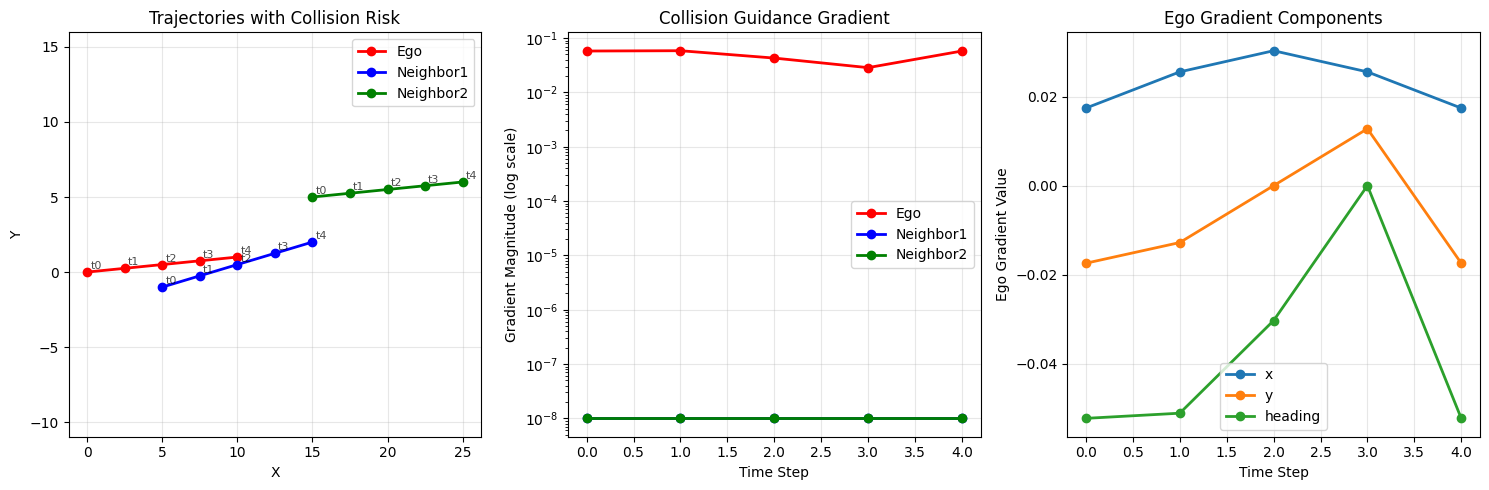

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def collision_guidance_fn(x, t, cond, inputs, *args, **kwargs):
    """
    碰撞引导函数 - 修复版本
    x: [B, P, T, 3] - (x, y, heading)
    """
    B, P, T, _ = x.shape
    device = x.device
    
    # 确保x需要梯度
    x = x.detach().requires_grad_(True)
    
    # 获取邻居信息
    neighbor_current_mask = inputs.get("neighbor_current_mask", torch.zeros(B, P-1, dtype=torch.bool, device=device))
    
    # 只在特定时间范围内应用引导,精细调整
    mask_diffusion_time = (t < 0.1) & (t > 0.005)
    if not mask_diffusion_time.any():
        return torch.zeros_like(x)
    
    print(f"=== 碰撞引导调试 ===")
    print(f"输入x形状: {x.shape}, 需要梯度: {x.requires_grad}")
    
    # 计算碰撞损失
    collision_loss = compute_collision_loss_simple(x, inputs)
    
    print(f"碰撞损失: {collision_loss.item()}, 需要梯度: {collision_loss.requires_grad}")
    
    # 计算梯度
    if collision_loss != 0 and collision_loss.requires_grad:
        grad_full = torch.autograd.grad(collision_loss, x, retain_graph=False)[0]
        
        print(f"完整梯度范数: {torch.norm(grad_full).item()}")
        
        # 关键修复：只保留自车梯度，其他交通参与者梯度置零
        grad_x = torch.zeros_like(x)
        grad_x[:, 0:1] = grad_full[:, 0:1]  # 只保留自车(索引0)的梯度
        
        ego_grad_norm = torch.norm(grad_x[:, 0]).item()
        ego_grad_mean = grad_x[:, 0].mean().item()
        ego_nonzero_ratio = (torch.abs(grad_x[:, 0]) > 1e-6).float().mean().item()
        
        print(f"自车梯度 - 范数: {ego_grad_norm:.6f}, 均值: {ego_grad_mean:.6f}, 非零比例: {ego_nonzero_ratio:.3f}")
        
        # 如果梯度还是太小，检查计算图问题
        if ego_grad_norm < 1e-6:
            print("⚠️ 警告：自车梯度太小，检查计算图连接")
            # 临时调试：显示梯度分量
            for d in range(3):
                dim_name = ["x", "y", "heading"][d]
                dim_grad_norm = torch.norm(grad_full[:, 0, :, d]).item()
                print(f"  自车{dim_name}梯度范数: {dim_grad_norm:.6f}")
                
    else:
        grad_x = torch.zeros_like(x)
        print("❌ 碰撞损失为0或不需要梯度")
    
    return grad_x

def compute_collision_loss_simple(x, inputs):
    """
    简化的碰撞损失计算 - 修复梯度连接问题
    """
    B, P, T, _ = x.shape
    device = x.device
    
    # 车辆尺寸 (长度, 宽度)
    ego_size = torch.tensor([4.0, 2.0], device=device)
    neighbor_size = torch.tensor([4.0, 2.0], device=device)
    
    total_loss = 0.0
    valid_pairs = 0
    
    # 只考虑自车与邻居的碰撞
    for b in range(B):
        for t in range(T):
            # 自车位置和方向 - 保持梯度连接
            ego_pos = x[b, 0, t, :2]  # [x, y] - 有梯度
            ego_heading = x[b, 0, t, 2]  # 有梯度
            
            for p in range(1, P):  # 邻居
                # 邻居位置和方向 - 也保持梯度连接
                neighbor_pos = x[b, p, t, :2]  # 有梯度
                neighbor_heading = x[b, p, t, 2]  # 有梯度
                
                # 计算边界框 - 修复梯度连接
                ego_bbox = get_rotated_bbox_with_grad(ego_pos, ego_heading, ego_size)
                neighbor_bbox = get_rotated_bbox_with_grad(neighbor_pos, neighbor_heading, neighbor_size)
                
                # 计算边界框距离
                distance = bbox_distance_with_grad(ego_bbox, neighbor_bbox)
                
                # 碰撞惩罚：距离越小，惩罚越大
                if distance < 5.0:  # 只在较近时计算
                    collision_penalty = torch.exp(-distance / 2.0)
                    total_loss += collision_penalty
                    valid_pairs += 1
                    
                    # 调试信息
                    if valid_pairs <= 3:  # 只打印前几个
                        print(f"  碰撞对 b{b}-t{t}-p{p}: 距离={distance.item():.3f}, 惩罚={collision_penalty.item():.6f}")
    
    if valid_pairs > 0:
        avg_loss = total_loss / valid_pairs
        print(f"有效碰撞对: {valid_pairs}, 平均损失: {avg_loss.item():.6f}")
        return avg_loss
    else:
        print("没有检测到碰撞风险")
        return torch.tensor(0.0, device=device)

def get_rotated_bbox_with_grad(center, heading, size):
    """
    计算旋转后的边界框角点 - 保持梯度连接
    """
    cos_h = torch.cos(heading)  # 保持梯度
    sin_h = torch.sin(heading)  # 保持梯度
    
    half_length = size[0] / 2
    half_width = size[1] / 2
    
    # 局部坐标下的四个角点
    corners_local = torch.tensor([
        [half_length, half_width],
        [half_length, -half_width],
        [-half_length, -half_width],
        [-half_length, half_width]
    ], device=center.device, dtype=torch.float32)
    
    # 旋转矩阵 - 关键修复：不使用detach()，保持梯度
    rotation_matrix = torch.stack([
        torch.stack([cos_h, -sin_h], dim=0),
        torch.stack([sin_h, cos_h], dim=0)
    ])  # [2, 2] - 保持梯度
    
    # 应用旋转和平移 - 保持梯度
    corners_rotated = torch.matmul(corners_local, rotation_matrix.T)
    corners_world = corners_rotated + center.unsqueeze(0)  # 保持梯度
    
    return corners_world

def bbox_distance_with_grad(bbox1, bbox2):
    """
    计算两个边界框之间的最小距离 - 保持梯度连接
    """
    min_distance = None
    
    # 计算所有角点对之间的距离
    for i in range(4):
        for j in range(4):
            dist = torch.norm(bbox1[i] - bbox2[j])
            if min_distance is None or dist < min_distance:
                min_distance = dist
    
    return min_distance

def expand_dims(tensor, target_dim):
    """维度扩展函数"""
    current_dim = tensor.dim()
    new_shape = tensor.shape + (1,) * (target_dim - current_dim)
    return tensor.reshape(new_shape)

def main():
    """验证碰撞引导函数的主函数"""
    print("=== 碰撞引导函数验证 ===\n")
    
    # 设置随机种子以便重现
    torch.manual_seed(42)
    
    # 模拟参数
    B = 2  # batch size
    P = 3  # 智能体数量 (1个ego + 2个邻居)
    T = 5  # 时间步数 (减少以便调试)
    D = 3  # 状态维度 (x, y, heading)
    
    print(f"模拟参数: B={B}, P={P}, T={T}, D={D}")
    
    # 生成模拟数据 - 创建有碰撞风险的场景
    print("\n1. 生成模拟轨迹数据...")
    
    # 生成自车轨迹
    ego_traj = torch.zeros(B, 1, T, D)
    for b in range(B):
        ego_traj[b, 0, :, 0] = torch.linspace(0, 10, T)  # x: 0->10
        ego_traj[b, 0, :, 1] = torch.linspace(0, 1, T)   # y: 0->1  
        ego_traj[b, 0, :, 2] = 0.0  # heading: 0度
    
    # 生成邻居轨迹 - 确保有碰撞风险
    neighbor_traj = torch.zeros(B, P-1, T, D)
    
    # 邻居1: 与自车有碰撞风险 (交叉轨迹)
    neighbor_traj[:, 0, :, 0] = torch.linspace(5, 15, T).unsqueeze(0)  # x: 5->15
    neighbor_traj[:, 0, :, 1] = torch.linspace(-1, 2, T).unsqueeze(0)  # y: -1->2 (与自车在t=2附近交叉)
    neighbor_traj[:, 0, :, 2] = 0.0
    
    # 邻居2: 安全距离
    neighbor_traj[:, 1, :, 0] = torch.linspace(15, 25, T).unsqueeze(0)  # x: 15->25
    neighbor_traj[:, 1, :, 1] = torch.linspace(5, 6, T).unsqueeze(0)    # y: 5->6 (安全距离)
    neighbor_traj[:, 1, :, 2] = 0.0
    
    # 合并所有轨迹
    x = torch.cat([ego_traj, neighbor_traj], dim=1)
    
    print(f"轨迹数据形状: {x.shape}")
    
    # 计算预期碰撞点
    print("\n预期碰撞分析:")
    for t in range(T):
        ego_pos = x[0, 0, t, :2]
        neighbor_pos = x[0, 1, t, :2]
        distance = torch.norm(ego_pos - neighbor_pos)
        print(f"时间步 {t}: 自车{ego_pos.detach().numpy()}, 邻居1{neighbor_pos.detach().numpy()}, 距离: {distance.item():.2f}")
    
    # 模拟输入数据
    print("\n2. 准备输入数据...")
    
    neighbor_current_mask = torch.zeros(B, P-1, dtype=torch.bool)
    
    # 时间步 (在引导时间范围内)
    t = torch.tensor([[0.05], [0.08]], dtype=torch.float32)
    
    inputs = {
        "neighbor_current_mask": neighbor_current_mask
    }
    
    cond = None
    
    print(f"时间步: {t.squeeze()}")
    
    # 测试碰撞引导函数
    print("\n3. 测试碰撞引导函数...")
    
    x_requires_grad = x.clone().requires_grad_(True)
    
    try:
        cond_grad = collision_guidance_fn(x_requires_grad, t, cond, inputs)
        print("✅ 碰撞引导函数执行成功!")
        print(f"梯度形状: {cond_grad.shape}")
        print(f"期望形状: {x.shape}")
        
        # 检查形状是否匹配
        if cond_grad.shape == x.shape:
            print("✅ 梯度形状正确!")
        else:
            print("❌ 梯度形状错误!")
        
        # 分析梯度
        print(f"\n4. 梯度分析:")
        print(f"整个梯度张量的范数: {torch.norm(cond_grad):.6f}")
        
        # 检查各智能体的梯度
        print(f"\n各智能体梯度分析:")
        for p in range(P):
            agent_type = "Ego" if p == 0 else f"Neighbor{p}"
            agent_grad = cond_grad[:, p]  # [B, T, 3]
            agent_norm = torch.norm(agent_grad).item()
            print(f"  {agent_type} 梯度范数: {agent_norm:.6f}")
            
            # 详细分析自车梯度
            if p == 0:
                for d in range(3):
                    dim_name = ["x", "y", "heading"][d]
                    dim_grad = agent_grad[..., d]
                    dim_norm = torch.norm(dim_grad).item()
                    dim_mean = dim_grad.mean().item()
                    print(f"    {dim_name}梯度 - 范数: {dim_norm:.6f}, 均值: {dim_mean:.6f}")
        
        # 检查是否有非零梯度
        non_zero_count = (torch.abs(cond_grad) > 1e-6).sum().item()
        total_elements = cond_grad.numel()
        print(f"\n非零梯度比例: {non_zero_count}/{total_elements} ({non_zero_count/total_elements*100:.2f}%)")
        
        # 测试在扩散模型中的应用
        print(f"\n5. 扩散模型引导测试:")
        
        # 模拟噪声预测
        noise_pred = torch.randn_like(x) * 0.1
        
        # 时间相关参数
        sigma_t = torch.tensor([0.5, 0.6])
        
        # 应用Classifier Guidance
        guidance_scale = 3.0
        sigma_t_expanded = expand_dims(sigma_t, x.dim())
        guided_noise = noise_pred - guidance_scale * sigma_t_expanded * cond_grad
        
        print(f"引导前噪声范数: {torch.norm(noise_pred):.6f}")
        print(f"引导后噪声范数: {torch.norm(guided_noise):.6f}")
        print(f"引导变化量: {torch.norm(guided_noise - noise_pred):.6f}")
        
        # 可视化
        visualize_simple(x, cond_grad)
        
    except Exception as e:
        print(f"❌ 错误: {e}")
        import traceback
        traceback.print_exc()

def visualize_simple(x, cond_grad):
    """简化可视化"""
    plt.figure(figsize=(15, 5))
    
    # 轨迹图
    plt.subplot(1, 3, 1)
    b = 0  # 只看第一个batch
    
    colors = ['red', 'blue', 'green']
    labels = ['Ego', 'Neighbor1', 'Neighbor2']
    
    for p in range(x.shape[1]):
        plt.plot(x[b, p, :, 0].detach().numpy(), 
                 x[b, p, :, 1].detach().numpy(), 
                 'o-', color=colors[p], label=labels[p], linewidth=2)
        
        # 在点上显示时间步
        for t in range(x.shape[2]):
            plt.text(x[b, p, t, 0].item() + 0.2, x[b, p, t, 1].item() + 0.2, 
                    f't{t}', fontsize=8, alpha=0.7)
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Trajectories with Collision Risk')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 梯度大小图 - 使用对数尺度
    plt.subplot(1, 3, 2)
    grad_magnitude = torch.norm(cond_grad, dim=-1)  # [B, P, T]
    
    for p in range(x.shape[1]):
        grad_values = grad_magnitude[0, p].detach().numpy()
        # 避免log(0)错误
        grad_values = np.maximum(grad_values, 1e-8)
        plt.semilogy(grad_values, 'o-', color=colors[p], label=labels[p], linewidth=2)
    
    plt.xlabel('Time Step')
    plt.ylabel('Gradient Magnitude (log scale)')
    plt.title('Collision Guidance Gradient')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 自车梯度分量分析
    plt.subplot(1, 3, 3)
    ego_grad = cond_grad[0, 0]  # [T, 3]
    components = ['x', 'y', 'heading']
    
    for d in range(3):
        plt.plot(ego_grad[:, d].detach().numpy(), 
                'o-', label=components[d], linewidth=2)
    
    plt.xlabel('Time Step')
    plt.ylabel('Ego Gradient Value')
    plt.title('Ego Gradient Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('collision_validation_fixed.png', dpi=150, bbox_inches='tight')
    print("\n✅ 可视化已保存为 'collision_validation_fixed.png'")

if __name__ == "__main__":
    main()